Défi quotidien : analyse des accidents d’avion et des décès

--- Structure initiale du jeu de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities 

C:\Users\GUE\AppData\Local\Temp\ipykernel_19928\2307728738.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values, y=top_regions.index, palette="mako")


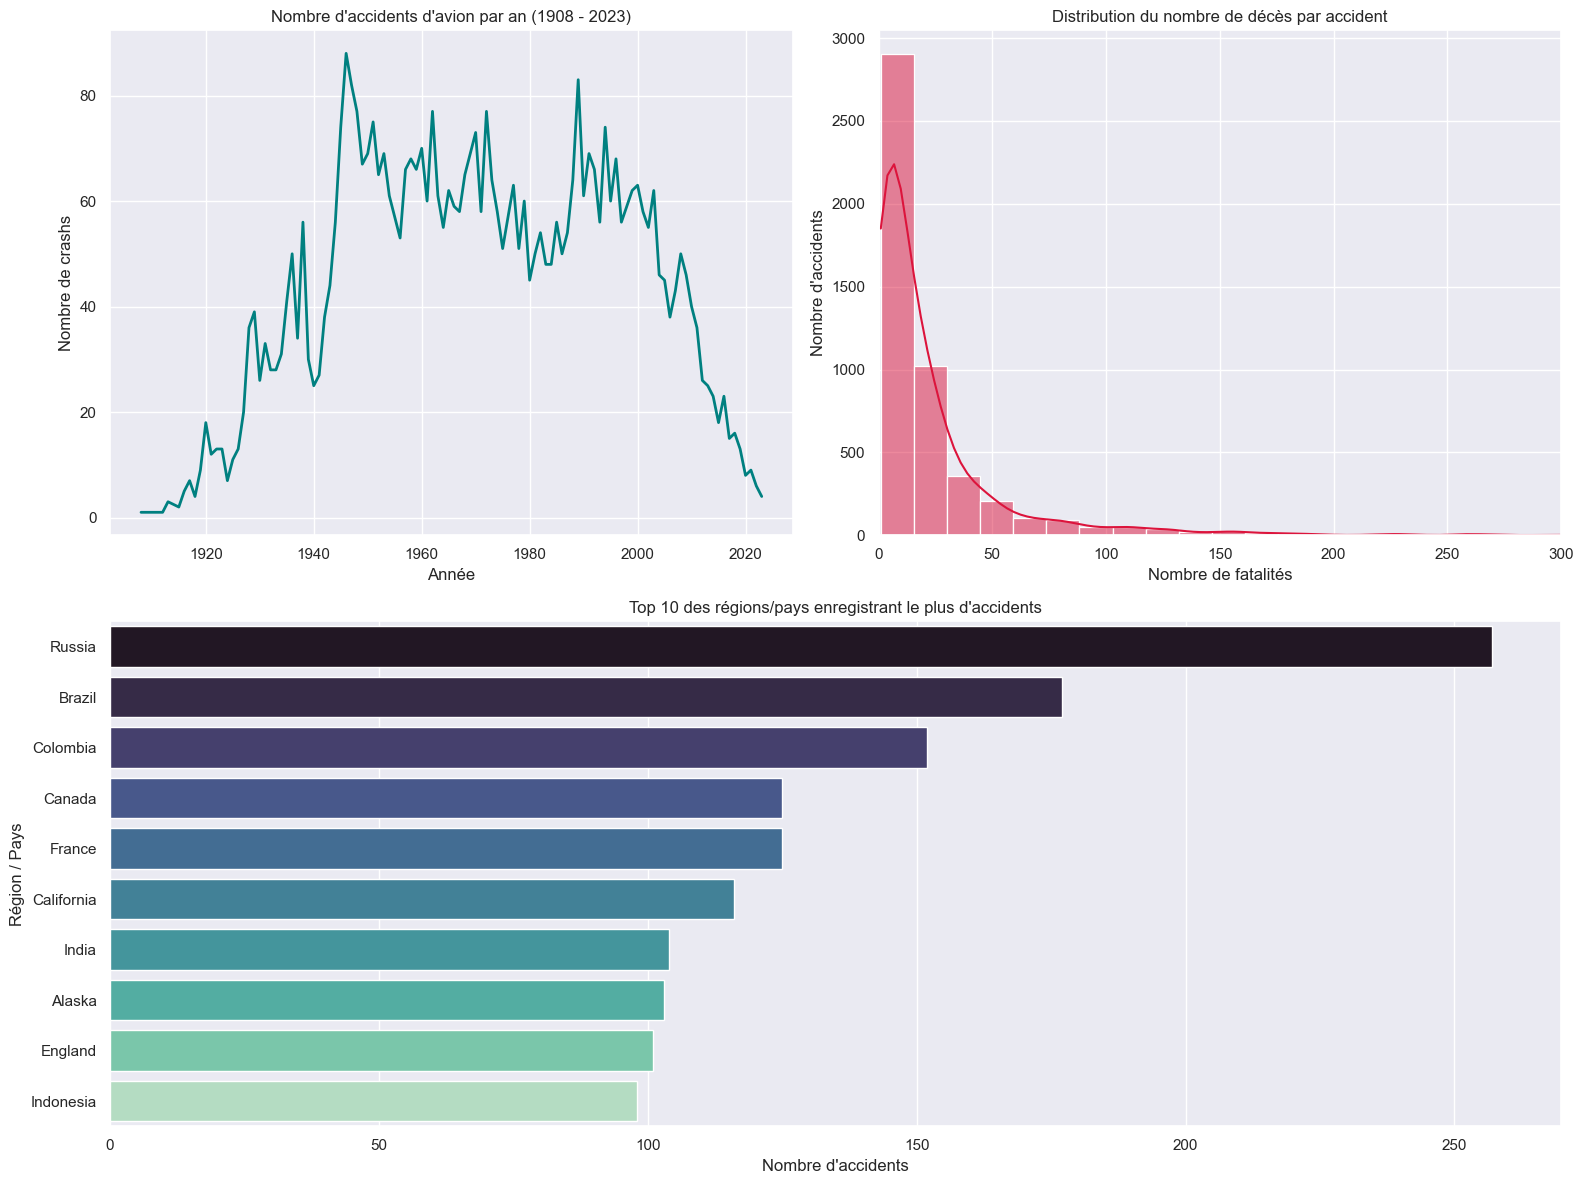

In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. IMPORTATION ET NETTOYAGE DES DONNÉES
# ==========================================

# Chargement du dataset
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')

print("--- Structure initiale du jeu de données ---")
print(df.info())

# Conversion de la colonne 'Date' en format DateTime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extraction de l'année et de la décennie
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

# Traitement des valeurs manquantes pour les données critiques
df['Fatalities'] = pd.to_numeric(df['Fatalities'], errors='coerce').fillna(0).astype(int)
df['Aboard'] = pd.to_numeric(df['Aboard'], errors='coerce').fillna(0).astype(int)

# Remplacement des textes manquants par 'Unknown'
df['Location'] = df['Location'].fillna('Unknown')
df['Operator'] = df['Operator'].fillna('Unknown')

# Calcul du taux de survie (Éviter la division par zéro grâce à np.where)
df['Survival_Rate'] = np.where(df['Aboard'] > 0, (df['Aboard'] - df['Fatalities']) / df['Aboard'], 0)


# ==========================================
# 2. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ==========================================

total_crashes = len(df)
total_fatalities = df['Fatalities'].sum()
avg_survival_rate = df['Survival_Rate'].mean() * 100

print("\n--- Statistiques Globales ---")
print(f"Nombre total d'accidents enregistrés : {total_crashes}")
print(f"Nombre total de décès : {total_fatalities}")
print(f"Taux de survie moyen par accident : {avg_survival_rate:.2f}%")

# Extraction des pays/régions à partir de la colonne Location (souvent le dernier élément après la virgule)
df['Region'] = df['Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else x)


# ==========================================
# 3. ANALYSE STATISTIQUE (SciPy)
# ==========================================

mean_fatal = np.mean(df['Fatalities'])
median_fatal = np.median(df['Fatalities'])
std_fatal = np.std(df['Fatalities'])

print("\n--- Métriques sur les Décès ---")
print(f"Moyenne : {mean_fatal:.2f} | Médiane : {median_fatal} | Écart-type : {std_fatal:.2f}")

# Test d'hypothèse : Comparaison de la moyenne des décès avant 1980 vs à partir de 1980
groupe_ancien = df[df['Year'] < 1980]['Fatalities']
groupe_moderne = df[df['Year'] >= 1980]['Fatalities']

t_stat, p_value = stats.ttest_ind(groupe_ancien, groupe_moderne, equal_var=False)

print("\n--- Test d'Hypothèse (T-Test Indépendant) ---")
print(f"Statistique T : {t_stat:.4f}")
print(f"P-value : {p_value:.4e}")

if p_value < 0.05:
    print("👉 Conclusion : Rejet de H0. Il y a une différence statistiquement significative du nombre moyen de décès par crash entre ces deux ères.")
else:
    print("👉 Conclusion : Échec du rejet de H0. Pas de différence statistique majeure.")


# ==========================================
# 4. VISUALISATION DES DONNÉES
# ==========================================

sns.set_theme(style="darkgrid")
plt.figure(figsize=(16, 12))

# Graphique 1 : Évolution temporelle des accidents
plt.subplot(2, 2, 1)
crashes_by_year = df['Year'].value_counts().sort_index()
sns.lineplot(x=crashes_by_year.index, y=crashes_by_year.values, color='teal', linewidth=2)
plt.title("Nombre d'accidents d'avion par an (1908 - 2023)", fontsize=12)
plt.xlabel("Année")
plt.ylabel("Nombre de crashs")

# Graphique 2 : Histogramme des décès
plt.subplot(2, 2, 2)
sns.histplot(df[df['Fatalities'] > 0]['Fatalities'], bins=40, kde=True, color='crimson')
plt.xlim(0, 300)  # Zoom pour une meilleure visibilité (exclut les pires anomalies)
plt.title("Distribution du nombre de décès par accident", fontsize=12)
plt.xlabel("Nombre de fatalités")
plt.ylabel("Nombre d'accidents")

# Graphique 3 : Top 10 des Régions/Pays avec le plus d'accidents
plt.subplot(2, 1, 2)
top_regions = df['Region'].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index, palette="mako")
plt.title("Top 10 des régions/pays enregistrant le plus d'accidents", fontsize=12)
plt.xlabel("Nombre d'accidents")
plt.ylabel("Région / Pays")

plt.tight_layout()
plt.show()